In [1]:
from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun
from langchain_community.utilities import ArxivAPIWrapper, WikipediaAPIWrapper

In [2]:
api_wrapper_arxiv = ArxivAPIWrapper(top_k_results=2, doc_content_chars_max=500)
arxiv = ArxivQueryRun(api_wrapper=api_wrapper_arxiv,description="Useful for searching research papers on arxiv")
print(arxiv.name)


arxiv


In [3]:
arxiv.invoke("What are some recent papers on deep learning?")

KeyboardInterrupt: 

In [4]:
api_wrapper_wikipedia = WikipediaAPIWrapper(top_k_results=2, doc_content_chars_max=500)
wikipedia = WikipediaQueryRun(api_wrapper=api_wrapper_wikipedia,description="Useful for searching information on wikipedia")    
print(wikipedia.name)

wikipedia


In [5]:
wikipedia.invoke("What is Artificial Intelligence? Explain in simple terms.")

"Page: Explainable artificial intelligence\nSummary: Within artificial intelligence (AI), explainable AI (XAI), generally overlapping with interpretable AI or explainable machine learning (XML), is a field of research that explores methods that provide humans with the ability of intellectual oversight over AI algorithms. The main focus is on the reasoning behind the decisions or predictions made by the AI algorithms, to make them more understandable and transparent. This addresses users' requireme"

In [6]:
from dotenv import load_dotenv
load_dotenv()

import os

os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")

In [7]:
from langchain_community.tools.tavily_search import TavilySearchResults
travily = TavilySearchResults()

/var/folders/9z/14rbqnqs78lfw5qqkljsxy6m0000gn/T/ipykernel_6658/3723431502.py:2: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  travily = TavilySearchResults()


In [8]:
travily.invoke("What are some recent news on Artificial Intelligence?")

[{'title': 'Breaking Tech News on May 8, 2026: AI Innovations, Space Races, and Industry Shifts - Coaio',
  'url': 'https://coaio.com/news/2026/05/breaking-tech-news-on-may-8-2026-ai-innovations-space-races-and-2pcc/',
  'content': 'engineering,’ emphasizing a more structured approach to AI-assisted development. This shift underscores the growing need for precise AI integration in coding, as discussed in a recent SD Times opinion piece Karpathy’s rename.Other AI news includes Google’s Gemma 4 models, which now feature a 3x speed boost through predictive token generation, maintaining quality while accelerating processes. OpenAI has expanded its API with new voice intelligence features, useful for customer service and education, as reported by TechCrunch OpenAI’s voice features. Additionally, Perplexity’s Personal Computer AI agent is now available on Mac, and Anthropic’s deal with SpaceX has led to raised usage limits for Claude Code, highlighting the intersection of AI and high-stakes 

In [9]:
tools = [arxiv, wikipedia, travily]

In [10]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

In [11]:
llm.invoke("What is Generative AI?")

AIMessage(content='Generative AI refers to a class of artificial intelligence models and systems that are designed to generate new content, data, or information based on the patterns and structures learned from existing data. Unlike traditional AI, which often focuses on classification or prediction tasks, generative AI creates new outputs that can resemble the training data in various forms, such as text, images, music, or even video.\n\nKey characteristics of generative AI include:\n\n1. **Learning from Data**: Generative AI models are trained on large datasets, learning the underlying patterns, structures, and relationships within the data.\n\n2. **Content Creation**: These models can produce new content that is similar to the training data. For example, they can generate realistic images, write coherent text, compose music, or create synthetic data for various applications.\n\n3. **Types of Models**: Common types of generative AI models include Generative Adversarial Networks (GANs

In [12]:
llm_with_tools = llm.bind_tools(tools=tools)

In [13]:
llm_with_tools.invoke("What are some latest research news on Artificial Intelligence?")

AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 147, 'total_tokens': 170, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_b37d70806b', 'id': 'chatcmpl-DeXxwXSfbETghs3SLHx1I2EDLwgOx', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019e1a33-b1fd-7300-9da8-f808d8d3c3f6-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'latest research news on Artificial Intelligence'}, 'id': 'call_XbgEoWCdCkzQMr7cb1V2vH9X', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 147, 'output_tokens': 23, 'total_tokens': 170, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_

In [14]:
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph.message import add_messages



/Users/rahul/projects-2026/langgraph-learn/.venv/lib/python3.13/site-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [15]:
class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

In [16]:
from IPython.display import Image,display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition



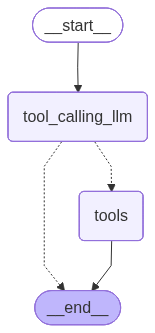

In [17]:
def tool_calling_llm(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}


builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm", tools_condition)
builder.add_edge("tools", END)

graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [24]:
from langchain_core.messages import HumanMessage

# messages = graph.invoke({"messages": HumanMessage(content="1706.03761")})
# messages = graph.invoke({"messages": "1706.03761"})
messages = graph.invoke({"messages": "Hi, my name is Rahul"})

for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

Hi, my name is Rahul
================================== Ai Message ==================================

Hello Rahul! How can I assist you today?


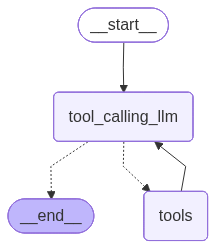

In [25]:
def tool_calling_llm(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}


builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm", tools_condition)
builder.add_edge("tools", "tool_calling_llm")
builder.add_edge("tool_calling_llm", END)

graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [27]:
from langchain_core.messages import HumanMessage

messages = graph.invoke({"messages": "Hi, my name is Rahul. What are the latest news on Artificial Intelligence and what is the recent research paper on quantum computing?"})

for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

Hi, my name is Rahul. What are the latest news on Artificial Intelligence and what is the recent research paper on quantum computing?
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (call_q5TnI9vAGmCc0pflrgqZovvB)
 Call ID: call_q5TnI9vAGmCc0pflrgqZovvB
  Args:
    query: latest news on Artificial Intelligence
  arxiv (call_thow8WrzYN6gXF7cxoQzlMuA)
 Call ID: call_thow8WrzYN6gXF7cxoQzlMuA
  Args:
    query: quantum computing
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "AI News | Latest News | Insights Powering AI-Driven Business Growth", "url": "https://www.artificialintelligence-news.com/", "content": "### NVIDIA and Google infrastructure cuts AI inference costs\n\n## Latest\n\nHealthcare & Wellness AI\n\nMay 7, 2026\n\n# AI helping ease the UK’s NHS 